✅ Đã set thư mục làm việc tại: C:\Users\vanqu\Nhom2_Data_08_Employee
⏳ Đang huấn luyện và trích xuất mô hình...
Bắt đầu quá trình Mô hình hóa (Supervised Learning)...
Kích thước tập Train: 1132 mẫu, Tập Test: 284 mẫu.

 Đang huấn luyện Random Forest (Baseline)...
Random Forest (Baseline) - F1-Score: 0.1224 | PR-AUC: 0.5515

 Đang huấn luyện XGBoost (Advanced)...
XGBoost (Advanced) - F1-Score: 0.4110 | PR-AUC: 0.4800
✅ Đã trích xuất thành công mô hình: Random Forest (Baseline)

BÁO CÁO ĐÁNH GIÁ MÔ HÌNH DỰ ĐOÁN NGHỈ VIỆC
               precision    recall  f1-score   support

    Ở lại (0)       0.85      1.00      0.92       238
Nghỉ việc (1)       1.00      0.07      0.12        46

     accuracy                           0.85       284
    macro avg       0.92      0.53      0.52       284
 weighted avg       0.87      0.85      0.79       284



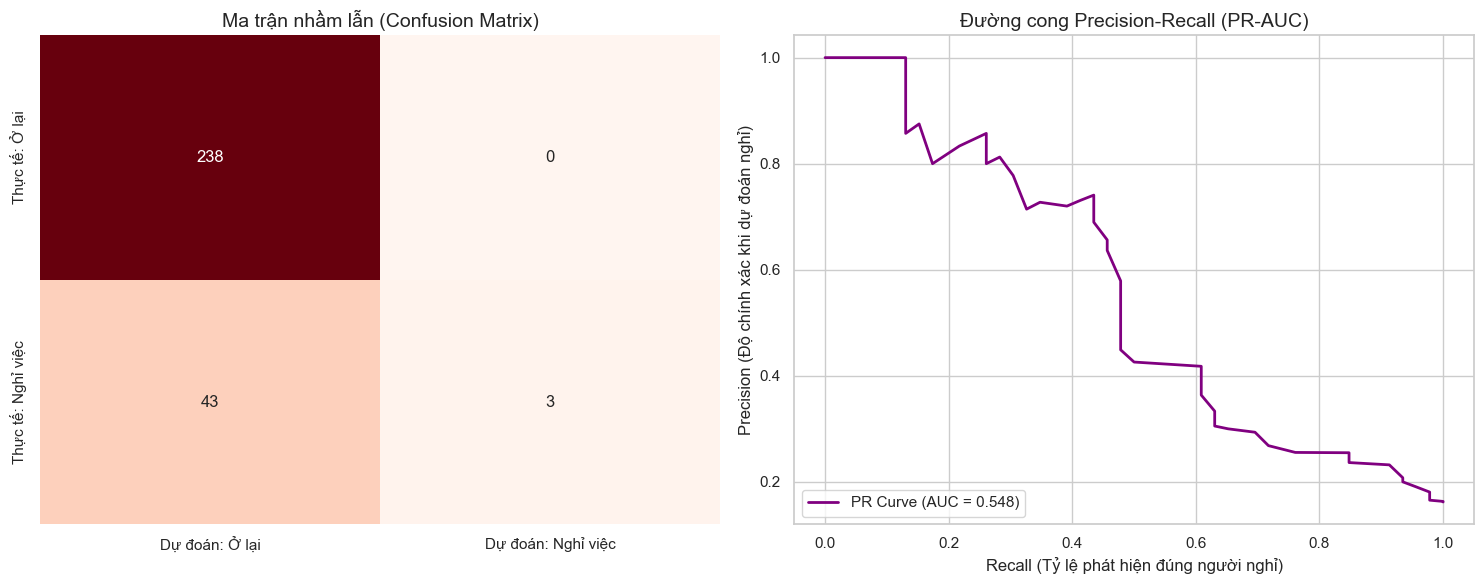

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1. Tự động dò tìm thư mục gốc của project
PROJECT_ROOT = os.getcwd()
while not os.path.exists(os.path.join(PROJECT_ROOT, 'src')):
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)
    if PROJECT_ROOT == os.path.dirname(PROJECT_ROOT):
        break

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
print(f"✅ Đã set thư mục làm việc tại: {os.getcwd()}")

# 2. Import hàm từ src của bác
from src.models.supervised import train_and_evaluate

# 3. Đọc dữ liệu
df_ml = pd.read_csv('data/processed/hr_ml_encoded.csv')

# 4. Chạy hàm để lấy model và test set trực tiếp từ RAM
print("⏳ Đang huấn luyện và trích xuất mô hình...")
results, X_test, y_test = train_and_evaluate(df_ml, target_col='Attrition', config_path='configs/params.yaml')

# 5. Lấy mô hình tốt nhất ra
best_model_name = list(results.keys())[0]
model = results[best_model_name]['model'] # Lấy object mô hình từ dictionary

print(f"✅ Đã trích xuất thành công mô hình: {best_model_name}")

# 6. Dự đoán kết quả
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n" + "="*55)
print("BÁO CÁO ĐÁNH GIÁ MÔ HÌNH DỰ ĐOÁN NGHỈ VIỆC")
print("="*55)
print(classification_report(y_test, y_pred, target_names=['Ở lại (0)', 'Nghỉ việc (1)']))

# 7. Trực quan hóa kết quả (Vẽ biểu đồ)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False, ax=axes[0],
            xticklabels=['Dự đoán: Ở lại', 'Dự đoán: Nghỉ việc'],
            yticklabels=['Thực tế: Ở lại', 'Thực tế: Nghỉ việc'])
axes[0].set_title('Ma trận nhầm lẫn (Confusion Matrix)', fontsize=14)

# Đường cong PR-AUC
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
axes[1].plot(recall, precision, color='purple', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
axes[1].set_xlabel('Recall (Tỷ lệ phát hiện đúng người nghỉ)')
axes[1].set_ylabel('Precision (Độ chính xác khi dự đoán nghỉ)')
axes[1].set_title('Đường cong Precision-Recall (PR-AUC)', fontsize=14)
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

In [ ]:
!pip install xgboost